# Explainable AML modeling — class-project MVP

This **one notebook** contains the data checks, modeling, evaluation, explanations, alert replay, and a small investigator-style review. It uses IBM's **synthetic HI-Small** transactions. The research comparison is logistic regression, XGBoost with Tree SHAP, and Explainable Boosting Machine (EBM), with currency-aware rules as a baseline.

**Study design:** sample 10% of September 1–10 transactions with seed 42; retain all September 11–18 rows as a separate stress check. Train on September 1–6, select a model on September 7–8, and evaluate on the September 9–10 holdout. DuckDB computes behavioral history from **every earlier transaction in the original CSV** before selecting sampled model rows.

Run cells from top to bottom. The first full run can take several minutes and needs free disk space for temporary DuckDB work. The notebook saves its **displayed outputs in this `.ipynb` file**; it does not create metrics, predictions, or a `results/` folder. The 454 MiB raw CSV remains a local input and is excluded from Git. Synthetic labels and weighted model scores are not real-world AML decisions or calibrated probabilities.

## 0. Setup

Create and select the project `.venv` kernel using the [README](README.md), then place `HI-Small_Trans.csv` in `data/raw/`. Only `DATA_PATH`, `SAMPLE_FRACTION`, and `SEED` are configuration. The code cells below contain the entire workflow.

In [1]:
from collections import Counter, defaultdict
from pathlib import Path
from tempfile import TemporaryDirectory
import gc
import sys

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, brier_score_loss, precision_recall_curve, roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

DATA_PATH = Path("data/raw/HI-Small_Trans.csv")
SAMPLE_FRACTION = 0.10
SEED = 42
ALERT_CAPACITY = 100
if not DATA_PATH.exists():
    raise FileNotFoundError(f"Download IBM HI-Small first; expected {DATA_PATH.resolve()}. See README.md.")
print(f"Python: {sys.version.split()[0]}")
print(f"IBM CSV: {DATA_PATH}")
print(f"Primary-period sample: {SAMPLE_FRACTION:.0%}; seed: {SEED}; alert capacity: {ALERT_CAPACITY}")

Python: 3.11.15
IBM CSV: data/raw/HI-Small_Trans.csv
Primary-period sample: 10%; seed: 42; alert capacity: 100


## 1. Read and profile the IBM CSV

The file is scanned in chunks, so the complete 5-million-row dataset is profiled without loading it all into pandas. At the same time, the code draws the fixed 10% modeling sample. It keeps every row from the unusual final eight days for a **separate stress check**. The source-row number is retained to verify feature alignment.

Full CSV: 5,078,345 transactions; 5,177 positive labels (0.102%)
Time: 2022-09-01 00:00:00 through 2022-09-18 16:18:00; missing values: 0
Sampled/model rows: 508,441


,rows,positives,label_rate_pct
2022-09-01,1114921,322,0.028881
2022-09-02,754449,408,0.054079
2022-09-03,207382,391,0.188541
2022-09-04,207430,407,0.196211
2022-09-05,482650,471,0.097586
2022-09-06,482089,531,0.110146
2022-09-07,482751,497,0.102952
2022-09-08,482773,539,0.111647
2022-09-09,654467,514,0.078537
2022-09-10,208325,442,0.212168


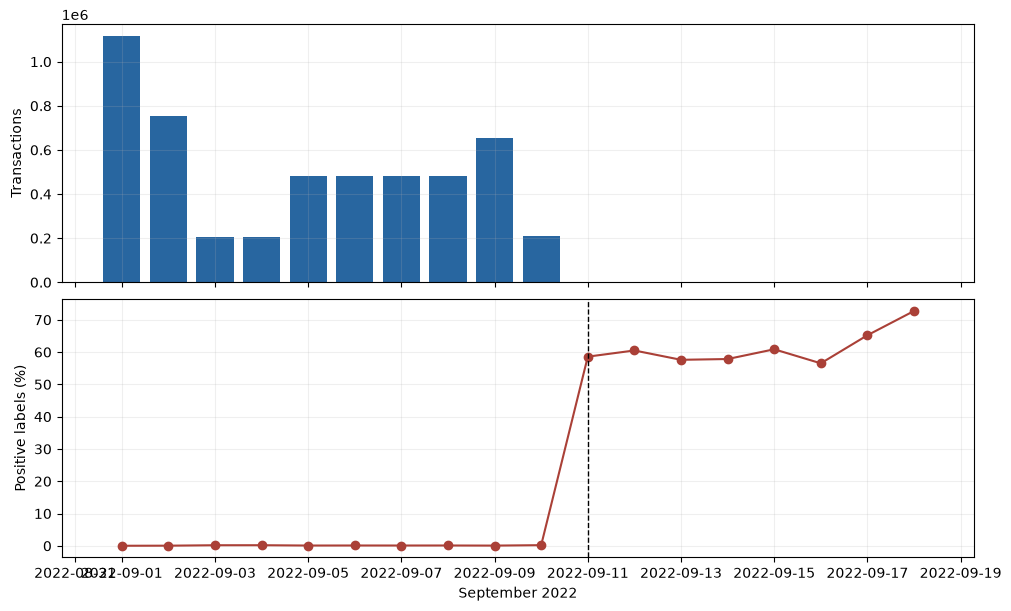

In [2]:
IBM_COLUMNS = [
    "timestamp", "from_bank", "from_account", "to_bank", "to_account",
    "amount_received", "receiving_currency", "amount_paid", "payment_currency",
    "payment_format", "is_laundering",
]
IBM_RAW_HEADER = [
    "Timestamp", "From Bank", "Account", "To Bank", "Account.1",
    "Amount Received", "Receiving Currency", "Amount Paid", "Payment Currency",
    "Payment Format", "Is Laundering",
]
TRAIN_END = pd.Timestamp("2022-09-07")
VALIDATION_END = pd.Timestamp("2022-09-09")
PRIMARY_END = pd.Timestamp("2022-09-11")

def load_profile_and_sample(path, fraction=0.10, seed=42, chunksize=100_000):
    if pd.read_csv(path, nrows=0).columns.tolist() != IBM_RAW_HEADER:
        raise ValueError("Expected IBM's 11-column HI-Small transaction CSV")
    if not 0 < fraction <= 1:
        raise ValueError("Sampling fraction must be in (0, 1]")
    rng = np.random.default_rng(seed)
    text_columns = ("from_bank", "from_account", "to_bank", "to_account",
                    "receiving_currency", "payment_currency", "payment_format")
    pieces, daily = [], defaultdict(lambda: [0, 0])
    formats, currencies = Counter(), Counter()
    missing = Counter()
    offset = positives = 0
    first_time = last_time = None
    for chunk in pd.read_csv(path, header=0, names=IBM_COLUMNS, chunksize=chunksize,
                             dtype={name: "string" for name in text_columns}):
        times = pd.to_datetime(chunk["timestamp"], errors="raise")
        labels = pd.to_numeric(chunk["is_laundering"], errors="raise")
        if not labels.isin([0, 1]).all():
            raise ValueError("Labels must be 0 or 1")
        missing.update(chunk.isna().sum().to_dict())
        formats.update(chunk["payment_format"].value_counts().to_dict())
        currencies.update(chunk["payment_currency"].value_counts().to_dict())
        for day, group in chunk.groupby(times.dt.date):
            daily[str(day)][0] += len(group)
            daily[str(day)][1] += int(group["is_laundering"].sum())
        positives += int(labels.sum())
        first_time = min(first_time, times.min()) if first_time is not None else times.min()
        last_time = max(last_time, times.max()) if last_time is not None else times.max()
        keep = ((times < PRIMARY_END) & (rng.random(len(chunk)) < fraction)) | (times >= PRIMARY_END)
        if keep.any():
            part = chunk.loc[keep].copy()
            part["source_row"] = np.flatnonzero(keep) + offset
            pieces.append(part)
        offset += len(chunk)
    if not pieces:
        raise ValueError("No modeling rows selected")
    sample = pd.concat(pieces, ignore_index=True)
    sample["timestamp"] = pd.to_datetime(sample["timestamp"])
    for col in ("amount_paid", "amount_received"):
        sample[col] = pd.to_numeric(sample[col], errors="raise")
    if sample[["amount_paid", "amount_received"]].isna().any().any() or \
       (sample[["amount_paid", "amount_received"]] < 0).any().any():
        raise ValueError("Transaction amounts must be nonnegative numbers")
    sample["is_laundering"] = sample["is_laundering"].astype("int8")
    sample = sample.sort_values("timestamp", kind="stable").reset_index(drop=True)
    profile = {"rows": offset, "positives": positives, "first": first_time,
               "last": last_time, "missing": dict(missing),
               "formats": dict(formats), "currencies": dict(currencies)}
    daily_frame = pd.DataFrame.from_dict(daily, orient="index", columns=["rows", "positives"])
    daily_frame.index = pd.to_datetime(daily_frame.index)
    daily_frame = daily_frame.sort_index()
    daily_frame["label_rate_pct"] = 100 * daily_frame["positives"] / daily_frame["rows"]
    return profile, daily_frame, sample

profile, daily_activity, transactions = load_profile_and_sample(DATA_PATH, SAMPLE_FRACTION, SEED)
assert profile["rows"] == 5_078_345, "CSV row count differs from the reported IBM HI-Small file"
print(f"Full CSV: {profile['rows']:,} transactions; {profile['positives']:,} positive labels "
      f"({profile['positives'] / profile['rows']:.3%})")
print(f"Time: {profile['first']} through {profile['last']}; missing values: {sum(profile['missing'].values())}")
print(f"Sampled/model rows: {len(transactions):,}")
display(daily_activity)
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True, layout="constrained")
axes[0].bar(daily_activity.index, daily_activity["rows"], color="#2866a0")
axes[0].set_ylabel("Transactions")
axes[1].plot(daily_activity.index, daily_activity["label_rate_pct"], marker="o", color="#aa4037")
axes[1].axvline(PRIMARY_END, color="black", linestyle="--", linewidth=1)
axes[1].set_ylabel("Positive labels (%)")
axes[1].set_xlabel("September 2022")
for ax in axes: ax.grid(alpha=.2)
plt.show()

## 2. Fix the chronological study windows

Training, validation, and test boundaries are set by calendar date before fitting. September 11–18 is excluded from model selection because its volume and label rate shift sharply. This late slice is shown only as a stress check.

In [3]:
def period_indexes(timestamps):
    return {
        "train": np.flatnonzero((timestamps < TRAIN_END).to_numpy()),
        "validation": np.flatnonzero(((timestamps >= TRAIN_END) & (timestamps < VALIDATION_END)).to_numpy()),
        "test": np.flatnonzero(((timestamps >= VALIDATION_END) & (timestamps < PRIMARY_END)).to_numpy()),
        "late_stress": np.flatnonzero((timestamps >= PRIMARY_END).to_numpy()),
    }

periods = period_indexes(transactions["timestamp"])
labels = transactions["is_laundering"].to_numpy()
period_summary = pd.DataFrame([
    {"period": name, "rows": len(indexes), "positive_labels": int(labels[indexes].sum()),
     "label_rate_pct": 100 * labels[indexes].mean()}
    for name, indexes in periods.items()
])
assert all(0 < labels[idx].sum() < len(idx) for idx in periods.values())
display(period_summary.round(4))

,period,rows,positive_labels,label_rate_pct
0,train,324521,260,0.0801
1,validation,96746,112,0.1158
2,test,86066,103,0.1197
3,late_stress,1108,655,59.1155


## 3. Build features from complete earlier history

DuckDB scans **all original rows** to calculate each sampled row's prior sender activity. Same-time transactions cannot see one another. Amount history stays within the payment currency; count history spans currencies. The database and spill files live in a temporary directory and are removed after this cell.

In [4]:
NUMERIC_FEATURES = [
    "log_amount_paid", "hour", "day_of_week", "same_bank",
    "prior_txn_count_24h", "prior_amount_24h", "prior_txn_count_7d",
    "prior_avg_amount_7d", "amount_vs_prior_avg_7d", "new_counterparty_7d",
]
CATEGORICAL_FEATURES = ["payment_format", "payment_currency", "receiving_currency"]
FEATURES = NUMERIC_FEATURES + CATEGORICAL_FEATURES
TRANSACTION_FEATURES = [
    "log_amount_paid", "hour", "day_of_week", "same_bank",
    "payment_format", "payment_currency", "receiving_currency",
]

def build_full_history_features(csv: Path, sampled: pd.DataFrame,
                                memory_limit: str = "2GB") -> pd.DataFrame:
    """Use disk-backed windows before selecting sampled rows.

    The CSV reader's ordinality is the original zero-based source row. Window
    frames exclude all same-timestamp peers, matching ``build_features``.
    """
    import duckdb

    if pd.read_csv(csv, nrows=0).columns.tolist() != IBM_RAW_HEADER:
        raise ValueError("Expected the 11-column IBM AML transaction CSV")
    with TemporaryDirectory(prefix="aml_history_") as temporary:
        temporary = Path(temporary)
        connection = duckdb.connect(
            str(temporary / "transactions.duckdb"),
            config={"memory_limit": memory_limit, "threads": "2",
                    "temp_directory": str(temporary / "spill")},
        )
        try:
            connection.execute("""
                CREATE TABLE transactions AS
                SELECT
                    src.ordinality - 1 AS source_row,
                    CAST(src."Timestamp" AS TIMESTAMP) AS timestamp,
                    src."From Bank" AS from_bank,
                    src."Account" AS from_account,
                    src."To Bank" AS to_bank,
                    src."Account_1" AS to_account,
                    CAST(src."Amount Paid" AS DOUBLE) AS amount_paid,
                    src."Payment Currency" AS payment_currency,
                    src."Receiving Currency" AS receiving_currency,
                    src."Payment Format" AS payment_format,
                    src."From Bank" || ':' || src."Account" AS sender,
                    src."To Bank" || ':' || src."Account_1" AS receiver
                FROM read_csv(?, all_varchar=true) WITH ORDINALITY AS src
            """, [str(csv)])
            selected = sampled[["source_row"]].copy()
            selected["position"] = range(len(selected))
            connection.register("selected", selected)
            result = connection.execute("""
                WITH rolling AS (
                    SELECT source_row, timestamp, from_bank, to_bank, amount_paid,
                           payment_format, payment_currency, receiving_currency,
                           count(*) OVER day_sender AS prior_txn_count_24h,
                           count(*) OVER week_sender AS prior_txn_count_7d,
                           sum(amount_paid) OVER day_currency AS prior_amount_24h,
                           avg(amount_paid) OVER week_currency AS prior_avg_amount_7d,
                           count(*) OVER week_counterparty AS prior_counterparty_count_7d
                    FROM transactions
                    WINDOW
                        day_sender AS (PARTITION BY sender ORDER BY timestamp
                            RANGE BETWEEN INTERVAL 1 DAY PRECEDING AND CURRENT ROW EXCLUDE GROUP),
                        week_sender AS (PARTITION BY sender ORDER BY timestamp
                            RANGE BETWEEN INTERVAL 7 DAYS PRECEDING AND CURRENT ROW EXCLUDE GROUP),
                        day_currency AS (PARTITION BY sender, payment_currency ORDER BY timestamp
                            RANGE BETWEEN INTERVAL 1 DAY PRECEDING AND CURRENT ROW EXCLUDE GROUP),
                        week_currency AS (PARTITION BY sender, payment_currency ORDER BY timestamp
                            RANGE BETWEEN INTERVAL 7 DAYS PRECEDING AND CURRENT ROW EXCLUDE GROUP),
                        week_counterparty AS (PARTITION BY sender, receiver ORDER BY timestamp
                            RANGE BETWEEN INTERVAL 7 DAYS PRECEDING AND CURRENT ROW EXCLUDE GROUP)
                )
                SELECT
                    ln(1 + rolling.amount_paid) AS log_amount_paid,
                    extract(hour FROM rolling.timestamp) AS hour,
                    extract(isodow FROM rolling.timestamp) - 1 AS day_of_week,
                    CAST(rolling.from_bank = rolling.to_bank AS INTEGER) AS same_bank,
                    rolling.prior_txn_count_24h,
                    greatest(coalesce(rolling.prior_amount_24h, 0), 0) AS prior_amount_24h,
                    rolling.prior_txn_count_7d,
                    coalesce(rolling.prior_avg_amount_7d, 0) AS prior_avg_amount_7d,
                    CASE WHEN rolling.prior_avg_amount_7d > 0
                         THEN rolling.amount_paid / rolling.prior_avg_amount_7d
                         ELSE 0 END AS amount_vs_prior_avg_7d,
                    CAST(rolling.prior_counterparty_count_7d = 0 AS INTEGER) AS new_counterparty_7d,
                    rolling.payment_format, rolling.payment_currency, rolling.receiving_currency
                FROM rolling
                JOIN selected USING (source_row)
                ORDER BY selected.position
            """).fetchdf()
            if len(result) != len(sampled):
                raise ValueError("Full-history query did not return every sampled row")
            if not np.allclose(result["log_amount_paid"].to_numpy(),
                               np.log1p(sampled["amount_paid"].to_numpy()), rtol=1e-10):
                raise ValueError("Full-history features do not align with sampled source rows")
            if not np.array_equal(result["payment_currency"].to_numpy(),
                                  sampled["payment_currency"].to_numpy()):
                raise ValueError("Full-history currencies do not align with sampled source rows")
            return result[FEATURES]
        finally:
            connection.close()

features = build_full_history_features(DATA_PATH, transactions)
assert len(features) == len(transactions)
print(f"Feature matrix: {features.shape[0]:,} rows × {features.shape[1]} columns")
display(features.head(5))

Feature matrix: 508,441 rows × 13 columns


,log_amount_paid,hour,day_of_week,same_bank,prior_txn_count_24h,prior_amount_24h,prior_txn_count_7d,prior_avg_amount_7d,amount_vs_prior_avg_7d,new_counterparty_7d,payment_format,payment_currency,receiving_currency
0,6.800582,0,3,1,0,0.0,0,0.0,0.0,1,Reinvestment,US Dollar,US Dollar
1,5.995357,0,3,1,0,0.0,0,0.0,0.0,1,Reinvestment,US Dollar,US Dollar
2,2.958549,0,3,1,0,0.0,0,0.0,0.0,1,Reinvestment,US Dollar,US Dollar
3,9.692166,0,3,1,0,0.0,0,0.0,0.0,1,Reinvestment,US Dollar,US Dollar
4,10.924854,0,3,1,0,0.0,0,0.0,0.0,1,Reinvestment,US Dollar,US Dollar


## 4. Define models, rules, and evaluation measures

The three ML models fit **training rows only**. Logistic regression and XGBoost encode categories; EBM uses named columns. The currency-aware rule thresholds are learned from training amounts only. Average precision (AP) is the main ranking metric; Precision/Recall@100 uses a fixed review capacity.

In [5]:
def _encoded_features(scale: bool, feature_columns: list[str]) -> ColumnTransformer:
    numeric = StandardScaler() if scale else "passthrough"
    return ColumnTransformer([
        ("numeric", numeric, [name for name in NUMERIC_FEATURES if name in feature_columns]),
        ("categorical", OneHotEncoder(handle_unknown="ignore"),
         [name for name in CATEGORICAL_FEATURES if name in feature_columns]),
    ])


def fit_model(name: str, x_train, y_train, seed: int = 42,
              feature_columns: list[str] | None = None):
    """Fit on the training period only; return an estimator with predict_proba."""
    if len(np.unique(y_train)) != 2:
        raise ValueError("Training period must contain both classes")
    feature_columns = feature_columns or FEATURES
    if set(feature_columns) != set(x_train.columns):
        raise ValueError("Training columns must match feature_columns")
    if name == "logistic":
        model = Pipeline([
            ("prepare", _encoded_features(scale=True, feature_columns=feature_columns)),
            ("model", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=seed)),
        ])
        return model.fit(x_train, y_train)
    if name == "xgboost":
        from xgboost import XGBClassifier

        positives = int(np.sum(y_train))
        negatives = len(y_train) - positives
        model = Pipeline([
            ("prepare", _encoded_features(scale=False, feature_columns=feature_columns)),
            ("model", XGBClassifier(
                n_estimators=200, max_depth=4, learning_rate=0.05,
                subsample=0.8, colsample_bytree=0.8,
                objective="binary:logistic", eval_metric="logloss",
                scale_pos_weight=negatives / positives,
                tree_method="hist", n_jobs=4, random_state=seed,
            )),
        ])
        return model.fit(x_train, y_train)
    if name == "ebm":
        from interpret.glassbox import ExplainableBoostingClassifier

        # EBM reads the named numeric and nominal columns directly, preserving
        # its additive terms for later explanation analysis.
        model = ExplainableBoostingClassifier(
            interactions=0, outer_bags=2, max_rounds=1500,
            n_jobs=4, random_state=seed,
        )
        positives = int(np.sum(y_train))
        negatives = len(y_train) - positives
        weights = np.where(np.asarray(y_train) == 1, len(y_train) / (2 * positives),
                           len(y_train) / (2 * negatives))
        return model.fit(x_train, y_train, sample_weight=weights)
    raise ValueError(f"Unknown model: {name}")


def top_k_metrics(y_true: np.ndarray, scores: np.ndarray, k: int) -> dict:
    if len(y_true) != len(scores) or k <= 0:
        raise ValueError("Invalid labels, scores, or alert capacity")
    k = min(k, len(scores))
    top = np.argsort(-scores, kind="stable")[:k]
    found = int(np.asarray(y_true)[top].sum())
    positives = int(np.asarray(y_true).sum())
    return {
        "alerts": k,
        "positives_found": found,
        "precision_at_k": found / k,
        "recall_at_k": found / positives if positives else None,
    }


def score_predictions(y_true: np.ndarray, scores: np.ndarray, k: int) -> dict:
    y_true = np.asarray(y_true)
    scores = np.asarray(scores)
    if not np.isfinite(scores).all() or ((scores < 0) | (scores > 1)).any():
        raise ValueError("Scores must be finite values between 0 and 1")
    result = top_k_metrics(y_true, scores, k)
    result.update({
        "rows": int(len(y_true)),
        "positives": int(y_true.sum()),
        "positive_rate": float(y_true.mean()),
        "pr_auc": float(average_precision_score(y_true, scores)) if y_true.sum() else None,
        "roc_auc": float(roc_auc_score(y_true, scores)) if len(np.unique(y_true)) == 2 else None,
        "brier_score": float(brier_score_loss(y_true, scores)),
    })
    return result


def fit_currency_rules(train: pd.DataFrame) -> dict[str, float]:
    """99th-percentile paid amount per currency, estimated on training only."""
    return train.groupby("payment_currency")["amount_paid"].quantile(.99).to_dict()


def currency_rule_scores(features: pd.DataFrame, transactions: pd.DataFrame,
                         thresholds: dict[str, float]) -> np.ndarray:
    cutoff = transactions["payment_currency"].map(thresholds).to_numpy(dtype=float)
    amount = transactions["amount_paid"].to_numpy(dtype=float)
    large = np.isfinite(cutoff) & (amount >= cutoff)
    frequent = features["prior_txn_count_24h"].to_numpy() >= 3
    relative = features["amount_vs_prior_avg_7d"].to_numpy() >= 5
    return (large.astype(float) + frequent + relative) / 3

## 5. Fit and compare the seven specifications

The rule baseline plus each ML algorithm with transaction-only and behavioral features gives seven specifications. The winning specification is chosen by **validation AP**. The September 9–10 test is inspected after that selection. All scores and metrics stay in memory for the remaining notebook sections.

In [6]:
def explain_model(name: str, model, columns: list[str],
                  features: pd.DataFrame, indexes: np.ndarray,
                  scores: np.ndarray, source_rows: np.ndarray) -> dict:
    """Export global terms and small local examples for the held-out period."""
    if name == "logistic":
        names = model["prepare"].get_feature_names_out()
        values = model["model"].coef_[0]
        order = np.argsort(-np.abs(values))[:20]
        return {"scale": "standardized numeric / one-hot category",
                "top_coefficients": [{"feature": str(names[i]), "coefficient": float(values[i])}
                                     for i in order]}
    if name == "xgboost":
        names = model["prepare"].get_feature_names_out()
        gain = model["model"].feature_importances_
        order = np.argsort(-gain)[:20]
        result = {"top_importances": [{"feature": str(names[i]), "importance": float(gain[i])}
                                      for i in order]}
        # XGBoost's native pred_contribs are exact Tree SHAP log-odds terms.
        import xgboost as xgb

        chosen = indexes[np.argsort(-scores)[:min(5, len(indexes))]]
        matrix = model["prepare"].transform(features.iloc[chosen][columns])
        contributions = model["model"].get_booster().predict(
            xgb.DMatrix(matrix), pred_contribs=True
        )
        result["local_tree_shap_log_odds"] = [
            {"source_row": int(source_rows[row]), "base_value": float(values[-1]),
             "top_terms": [{"feature": str(names[i]), "contribution": float(values[i])}
                           for i in np.argsort(-np.abs(values[:-1]))[:10]]}
            for row, values in zip(chosen, contributions)
        ]
        return result
    if name == "ebm":
        importances = model.term_importances()
        order = np.argsort(-importances)[:20]
        return {"top_terms": [{"term": str(model.term_names_[i]),
                               "importance": float(importances[i])} for i in order]}
    raise ValueError(name)

In [7]:
thresholds = fit_currency_rules(transactions.iloc[periods["train"]])
specs = [("rules", "behavioral", FEATURES)] + [
    (name, feature_set, columns)
    for feature_set, columns in (("transaction", TRANSACTION_FEATURES), ("behavioral", FEATURES))
    for name in ("logistic", "xgboost", "ebm")
]
metrics, explanations, prediction_parts = {}, {}, []
for name, feature_set, columns in specs:
    key = f"{name}_{feature_set}"
    model = None if name == "rules" else fit_model(
        name, features.iloc[periods["train"]][columns], labels[periods["train"]],
        seed=SEED, feature_columns=columns,
    )
    metrics[key] = {}
    for period in ("validation", "test", "late_stress"):
        indexes = periods[period]
        x = features.iloc[indexes][columns]
        scores = (currency_rule_scores(features.iloc[indexes], transactions.iloc[indexes], thresholds)
                  if model is None else model.predict_proba(x)[:, 1])
        metrics[key][period] = score_predictions(labels[indexes], scores, ALERT_CAPACITY)
        prediction_parts.append(pd.DataFrame({
            "source_row": transactions.iloc[indexes]["source_row"].to_numpy(),
            "timestamp": transactions.iloc[indexes]["timestamp"].to_numpy(),
            "period": period, "model": key, "label": labels[indexes], "score": scores,
            "payment_currency": transactions.iloc[indexes]["payment_currency"].to_numpy(),
        }))
        if period == "test":
            test_scores = scores
    if model is not None:
        explanations[key] = explain_model(name, model, columns, features,
                                          periods["test"], test_scores,
                                          transactions["source_row"].to_numpy())
    print(f"{key}: validation AP {metrics[key]['validation']['pr_auc']:.4f}; "
          f"primary-test AP {metrics[key]['test']['pr_auc']:.4f}")
    del model
    gc.collect()
predictions = pd.concat(prediction_parts, ignore_index=True)
del prediction_parts
selected_model = max(metrics, key=lambda key: metrics[key]["validation"]["pr_auc"])
comparison = pd.DataFrame([
    {"specification": key,
     "validation_AP": value["validation"]["pr_auc"],
     "primary_test_AP": value["test"]["pr_auc"],
     "test_labels_in_top_100": value["test"]["positives_found"],
     "test_precision_at_100": value["test"]["precision_at_k"],
     "test_recall_at_100": value["test"]["recall_at_k"]}
    for key, value in metrics.items()
])
print(f"Validation-selected specification: {selected_model}")
display(comparison.round(4))

rules_behavioral: validation AP 0.0010; primary-test AP 0.0011


logistic_transaction: validation AP 0.0120; primary-test AP 0.0135


xgboost_transaction: validation AP 0.0336; primary-test AP 0.0459


ebm_transaction: validation AP 0.0185; primary-test AP 0.0250


logistic_behavioral: validation AP 0.0133; primary-test AP 0.0111


xgboost_behavioral: validation AP 0.3362; primary-test AP 0.2245


ebm_behavioral: validation AP 0.1519; primary-test AP 0.1105
Validation-selected specification: xgboost_behavioral


,specification,validation_AP,primary_test_AP,test_labels_in_top_100,test_precision_at_100,test_recall_at_100
0,rules_behavioral,0.0010,0.0011,0,0.00,0.0000
1,logistic_transaction,0.0120,0.0135,1,0.01,0.0097
2,xgboost_transaction,0.0336,0.0459,12,0.12,0.1165
3,ebm_transaction,0.0185,0.0250,1,0.01,0.0097
4,logistic_behavioral,0.0133,0.0111,0,0.00,0.0000
5,xgboost_behavioral,0.3362,0.2245,23,0.23,0.2233
6,ebm_behavioral,0.1519,0.1105,18,0.18,0.1748


## 6. View model performance

Compare validation and holdout AP, then inspect precision–recall and detections within a fixed alert budget. The late stress period is kept separate because its positive-label prevalence differs dramatically.

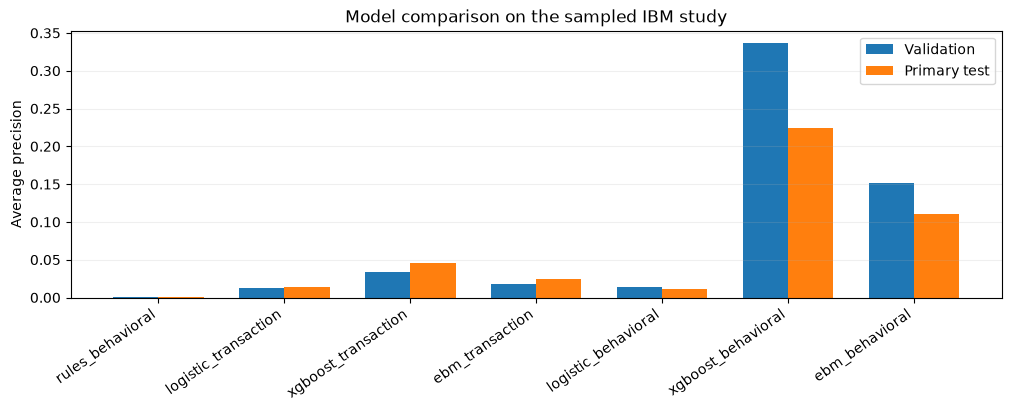

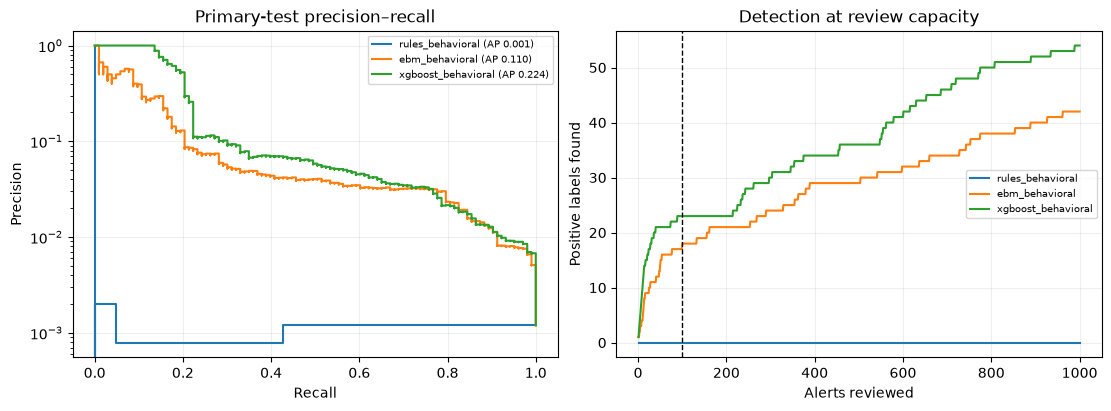

Late-period AP is a stress diagnostic; its different label prevalence makes direct AP comparison misleading.


In [8]:
fig, ax = plt.subplots(figsize=(10, 4), layout="constrained")
x = np.arange(len(comparison))
ax.bar(x - .18, comparison["validation_AP"], width=.36, label="Validation")
ax.bar(x + .18, comparison["primary_test_AP"], width=.36, label="Primary test")
ax.set_xticks(x, comparison["specification"], rotation=35, ha="right")
ax.set_ylabel("Average precision")
ax.set_title("Model comparison on the sampled IBM study")
ax.legend()
ax.grid(axis="y", alpha=.2)
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(11, 4), layout="constrained")
for name in dict.fromkeys(["rules_behavioral", "ebm_behavioral", selected_model]):
    part = predictions.loc[(predictions["model"] == name) & (predictions["period"] == "test")]
    y, scores = part["label"].to_numpy(), part["score"].to_numpy()
    precision, recall, _ = precision_recall_curve(y, scores)
    axes[0].step(recall, precision, where="post", label=f"{name} (AP {average_precision_score(y, scores):.3f})")
    ranked = y[np.argsort(-scores, kind="stable")]
    axes[1].plot(np.arange(1, 1001), np.cumsum(ranked)[:1000], label=name)
axes[0].set(xlabel="Recall", ylabel="Precision", title="Primary-test precision–recall")
axes[0].set_yscale("log")
axes[1].axvline(ALERT_CAPACITY, color="black", linestyle="--", linewidth=1)
axes[1].set(xlabel="Alerts reviewed", ylabel="Positive labels found", title="Detection at review capacity")
for ax in axes:
    ax.legend(fontsize=7)
    ax.grid(alpha=.2)
plt.show()
print("Late-period AP is a stress diagnostic; its different label prevalence makes direct AP comparison misleading.")

## 7. Inspect errors and uncertainty

The top 100 alerts and highest-scored missed positives are kept as DataFrames, not CSV files. A 300-repeat stratified **row** bootstrap gives a descriptive AP interval; it does not capture account or time dependence.

In [9]:
def bootstrap_ap(y: np.ndarray, scores: np.ndarray, seed: int = 42,
                 repeats: int = 200) -> tuple[float, float]:
    """Stratified row bootstrap, keeping observed test prevalence fixed."""
    positives = np.flatnonzero(y == 1)
    negatives = np.flatnonzero(y == 0)
    if not len(positives) or not len(negatives):
        raise ValueError("Bootstrap requires both classes")
    rng = np.random.default_rng(seed)
    values = []
    for _ in range(repeats):
        draw = np.concatenate((rng.choice(positives, len(positives)),
                               rng.choice(negatives, len(negatives))))
        values.append(average_precision_score(y[draw], scores[draw]))
    return tuple(float(v) for v in np.quantile(values, [.025, .975]))

selected_test = (predictions.loc[(predictions["model"] == selected_model) &
                                 (predictions["period"] == "test")]
                 .sort_values("score", ascending=False, kind="stable").reset_index(drop=True))
top_alerts = selected_test.head(ALERT_CAPACITY).copy()
top_alerts.insert(0, "alert_rank", np.arange(1, len(top_alerts) + 1))
missed_positives = selected_test.iloc[ALERT_CAPACITY:].loc[lambda frame: frame["label"] == 1]
interval = bootstrap_ap(selected_test["label"].to_numpy(), selected_test["score"].to_numpy(),
                        seed=SEED, repeats=300)
print(f"Top {ALERT_CAPACITY}: {int(top_alerts['label'].sum())} positive labels, "
      f"{ALERT_CAPACITY - int(top_alerts['label'].sum())} negative labels")
print(f"Positive labels below capacity: {len(missed_positives)}")
print(f"Descriptive 95% AP interval: {interval[0]:.4f}–{interval[1]:.4f}")
display(top_alerts.head(10))
print("Highest-scored missed positive labels:")
display(missed_positives.head(10))
segments = pd.DataFrame([
    {"payment_currency": currency, "rows": len(group),
     "positives": int(group["label"].sum()),
     "AP": (average_precision_score(group["label"], group["score"])
            if 0 < group["label"].sum() < len(group) else np.nan)}
    for currency, group in selected_test.groupby("payment_currency")
]).sort_values("rows", ascending=False)
display(segments.round(4))

Top 100: 23 positive labels, 77 negative labels
Positive labels below capacity: 80
Descriptive 95% AP interval: 0.1468–0.3128


,alert_rank,source_row,timestamp,period,model,label,score,payment_currency
0,1,3459535,2022-09-10 11:13:00,test,xgboost_behavioral,1,0.997553,US Dollar
1,2,4887997,2022-09-10 18:39:00,test,xgboost_behavioral,1,0.997352,US Dollar
2,3,4683032,2022-09-10 11:54:00,test,xgboost_behavioral,1,0.997142,Euro
3,4,3117691,2022-09-10 08:39:00,test,xgboost_behavioral,1,0.996361,Euro
4,5,4974359,2022-09-10 10:51:00,test,xgboost_behavioral,1,0.995921,Euro
5,6,3961342,2022-09-09 08:30:00,test,xgboost_behavioral,1,0.995544,US Dollar
6,7,3249689,2022-09-10 17:11:00,test,xgboost_behavioral,1,0.995426,US Dollar
7,8,4683036,2022-09-10 11:16:00,test,xgboost_behavioral,1,0.995154,Yuan
8,9,3303613,2022-09-09 12:19:00,test,xgboost_behavioral,1,0.994368,Euro
9,10,4389507,2022-09-09 12:54:00,test,xgboost_behavioral,1,0.993482,Australian Dollar


Highest-scored missed positive labels:


,source_row,timestamp,period,model,label,score,payment_currency
214,4719761,2022-09-09 18:19:00,test,xgboost_behavioral,1,0.950278,Rupee
224,2387745,2022-09-10 08:56:00,test,xgboost_behavioral,1,0.949076,Yen
232,4951340,2022-09-10 08:08:00,test,xgboost_behavioral,1,0.948352,US Dollar
236,4986475,2022-09-10 12:03:00,test,xgboost_behavioral,1,0.948170,Saudi Riyal
242,3123433,2022-09-09 05:43:00,test,xgboost_behavioral,1,0.947433,US Dollar
261,4214986,2022-09-10 00:52:00,test,xgboost_behavioral,1,0.945062,US Dollar
296,4977624,2022-09-10 11:08:00,test,xgboost_behavioral,1,0.942253,Canadian Dollar
303,4696412,2022-09-09 17:07:00,test,xgboost_behavioral,1,0.941414,Saudi Riyal
345,4939862,2022-09-10 06:31:00,test,xgboost_behavioral,1,0.934811,Euro
353,3906810,2022-09-09 22:47:00,test,xgboost_behavioral,1,0.933715,Euro


,payment_currency,rows,positives,AP
12,US Dollar,32212,32,0.2532
4,Euro,19854,32,0.2334
10,Swiss Franc,3878,1,0.5000
14,Yuan,3669,7,0.4434
7,Rupee,3283,3,0.1888
9,Shekel,3232,4,0.0189
11,UK Pound,3027,2,0.0215
6,Ruble,2674,3,0.3581
13,Yen,2653,3,0.3995
0,Australian Dollar,2353,6,0.3723


## 8. Explain the scores

Logistic coefficients, XGBoost importance and Tree SHAP, and EBM global terms are shown together. Tree SHAP contributions are on the model's **raw log-odds** scale. These are explanations of model behavior, not causal evidence about laundering.

In [10]:
print("Logistic regression: largest behavioral coefficients")
display(pd.DataFrame(explanations["logistic_behavioral"]["top_coefficients"]).head(10).round(4))
print("XGBoost: leading behavioral-feature importances")
display(pd.DataFrame(explanations["xgboost_behavioral"]["top_importances"]).head(10).round(4))
print("EBM: leading global terms")
display(pd.DataFrame(explanations["ebm_behavioral"]["top_terms"]).head(10).round(4))
local_shap = explanations["xgboost_behavioral"]["local_tree_shap_log_odds"][0]
print(f"Tree SHAP for high-ranked source row {local_shap['source_row']}; "
      f"base margin {local_shap['base_value']:.3f} log odds")
display(pd.DataFrame(local_shap["top_terms"]).round(4))

Logistic regression: largest behavioral coefficients


,feature,coefficient
0,numeric__amount_vs_prior_avg_7d,-8.3296
1,categorical__payment_format_Reinvestment,-7.0671
2,categorical__payment_format_Wire,-5.5537
3,categorical__payment_format_ACH,4.9634
4,categorical__payment_currency_Yuan,-2.9362
5,categorical__receiving_currency_Yuan,2.2377
6,categorical__payment_currency_US Dollar,-2.1130
7,categorical__payment_format_Bitcoin,1.9377
8,categorical__payment_currency_Bitcoin,1.8880
9,categorical__receiving_currency_UK Pound,1.8320


XGBoost: leading behavioral-feature importances


,feature,importance
0,categorical__payment_format_ACH,0.2377
1,categorical__payment_format_Reinvestment,0.0989
2,numeric__new_counterparty_7d,0.0527
3,categorical__payment_format_Cheque,0.0501
4,numeric__same_bank,0.0497
5,numeric__prior_txn_count_7d,0.0468
6,categorical__payment_format_Credit Card,0.0467
7,categorical__payment_currency_Saudi Riyal,0.0343
8,numeric__prior_txn_count_24h,0.0268
9,categorical__receiving_currency_Saudi Riyal,0.0176


EBM: leading global terms


,term,importance
0,payment_format,2.4242
1,new_counterparty_7d,1.1540
2,prior_txn_count_7d,0.5504
3,amount_vs_prior_avg_7d,0.4765
4,prior_txn_count_24h,0.4481
5,log_amount_paid,0.4405
6,prior_amount_24h,0.3268
7,day_of_week,0.2699
8,payment_currency,0.2385
9,same_bank,0.2247


Tree SHAP for high-ranked source row 3459535; base margin 0.660 log odds


,feature,contribution
0,categorical__payment_format_ACH,2.7552
1,numeric__new_counterparty_7d,0.6946
2,numeric__prior_avg_amount_7d,0.5402
3,numeric__amount_vs_prior_avg_7d,0.4398
4,numeric__log_amount_paid,0.3628
5,numeric__prior_amount_24h,0.2728
6,numeric__day_of_week,0.1825
7,categorical__payment_format_Credit Card,0.0598
8,categorical__payment_format_Cheque,0.0529
9,categorical__payment_format_Reinvestment,0.0428


## 9. Replay the saved scores in memory

This optional monitoring illustration chooses a score cutoff using **validation scores only**, targeting 100 alerts per validation day. It replays test and late-stress scores in timestamp order. It does not retrain or score live transactions, and it writes no files.

Validation-only score cutoff: 0.949697


,date,period,transactions,labels,alerts,labels_in_alerts
0,2022-09-09,test,65197,59,22,9
1,2022-09-10,test,20869,44,199,15
2,2022-09-11,late_stress,396,232,137,126
3,2022-09-12,late_stress,281,170,114,105
4,2022-09-13,late_stress,184,106,54,50
5,2022-09-14,late_stress,121,70,36,33
6,2022-09-15,late_stress,46,28,16,16
7,2022-09-16,late_stress,46,26,13,13
8,2022-09-17,late_stress,23,15,11,11
9,2022-09-18,late_stress,11,8,7,7


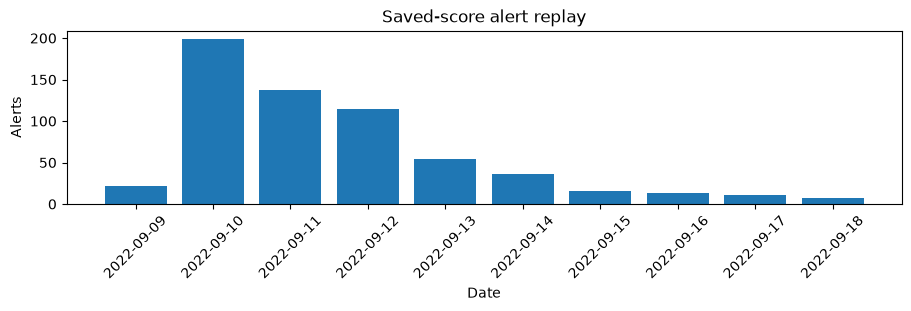

In [11]:
def threshold_for_daily_capacity(validation: pd.DataFrame,
                                 daily_capacity: int) -> float:
    """Set the score cutoff from validation days without reading labels."""
    if daily_capacity <= 0 or validation.empty:
        raise ValueError("Need validation scores and a positive daily capacity")
    days = validation["timestamp"].dt.normalize().nunique()
    allowed = min(len(validation), daily_capacity * days)
    scores = validation["score"].to_numpy(dtype=float)
    return float(np.partition(scores, -allowed)[-allowed])

selected_predictions = predictions.loc[predictions["model"] == selected_model].copy()
validation_scores = selected_predictions.loc[selected_predictions["period"] == "validation"]
cutoff = threshold_for_daily_capacity(validation_scores, daily_capacity=100)
replay = (selected_predictions.loc[selected_predictions["period"].isin(["test", "late_stress"])]
          .sort_values(["timestamp", "source_row"], kind="stable").copy())
replay["alert"] = replay["score"] >= cutoff
replay["date"] = replay["timestamp"].dt.date.astype(str)
daily_replay = replay.groupby(["date", "period"], sort=True).agg(
    transactions=("score", "size"), labels=("label", "sum"), alerts=("alert", "sum")
).reset_index()
found = replay.loc[replay["alert"]].groupby("date")["label"].sum()
daily_replay["labels_in_alerts"] = daily_replay["date"].map(found).fillna(0).astype(int)
print(f"Validation-only score cutoff: {cutoff:.6f}")
display(daily_replay)
fig, ax = plt.subplots(figsize=(9, 3), layout="constrained")
ax.bar(daily_replay["date"], daily_replay["alerts"])
ax.set(title="Saved-score alert replay", ylabel="Alerts", xlabel="Date")
ax.tick_params(axis="x", rotation=45)
plt.show()

## 10. Investigator-style review in the notebook

This replaces the separate Streamlit dashboard. Change `REVIEW_MODEL`, `REVIEW_PERIOD`, `REVIEW_CAPACITY`, or `CASE_RANK`, then rerun the cell. It shows a ranked queue, one synthetic case, the sender's **complete earlier seven-day history** from the original CSV, counterparties, and available model explanations. No case notes or raw rows are exported.

xgboost_behavioral • test: 86,066 rows, 103 positives, AP 0.2245
Top 100: 23 positive labels; precision 23.0%


,alert_rank,source_row,timestamp,payment_currency,label,score
0,1,3459535,2022-09-10 11:13:00,US Dollar,1,0.997553
1,2,4887997,2022-09-10 18:39:00,US Dollar,1,0.997352
2,3,4683032,2022-09-10 11:54:00,Euro,1,0.997142
3,4,3117691,2022-09-10 08:39:00,Euro,1,0.996361
4,5,4974359,2022-09-10 10:51:00,Euro,1,0.995921
5,6,3961342,2022-09-09 08:30:00,US Dollar,1,0.995544
6,7,3249689,2022-09-10 17:11:00,US Dollar,1,0.995426
7,8,4683036,2022-09-10 11:16:00,Yuan,1,0.995154
8,9,3303613,2022-09-09 12:19:00,Euro,1,0.994368
9,10,4389507,2022-09-09 12:54:00,Australian Dollar,1,0.993482


Case at alert rank 1:


,timestamp,from_bank,from_account,to_bank,to_account,amount_paid,payment_currency,payment_format,is_laundering
496880,2022-09-10 11:13:00,015,803D8E3A0,017732,80FCBD920,15194.76,US Dollar,ACH,1


Earlier seven-day sender transactions: 18


,timestamp,to_bank,to_account,amount_paid,payment_currency,payment_format
2,2022-09-04 23:32:00,009665,804483350,55429.24,Yen,Cash
0,2022-09-04 23:35:00,009665,804483350,60508.31,Yen,Cheque
1,2022-09-04 23:43:00,009665,804483350,45960.14,Yen,Credit Card
5,2022-09-05 10:47:00,009665,804483350,55429.24,Yen,Cash
4,2022-09-05 10:49:00,009665,804483350,45960.14,Yen,Credit Card
3,2022-09-05 10:57:00,009665,804483350,60508.31,Yen,Cheque
7,2022-09-06 18:58:00,009665,804483350,45960.14,Yen,Credit Card
8,2022-09-06 18:59:00,009665,804483350,55429.24,Yen,Cash
6,2022-09-06 18:59:00,009665,804483350,60508.31,Yen,Cheque
9,2022-09-07 09:35:00,009665,804483350,60508.31,Yen,Cheque


,to_bank,to_account,transactions
0,009665,804483350,18


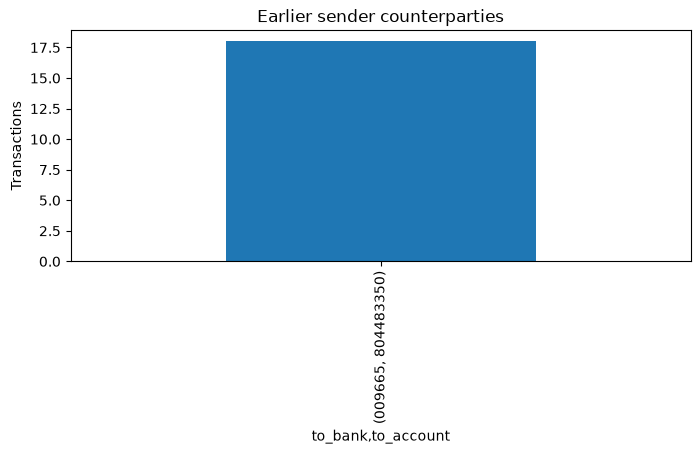

Local Tree SHAP contributions (log-odds):


,feature,contribution
0,categorical__payment_format_ACH,2.7552
1,numeric__new_counterparty_7d,0.6946
2,numeric__prior_avg_amount_7d,0.5402
3,numeric__amount_vs_prior_avg_7d,0.4398
4,numeric__log_amount_paid,0.3628
5,numeric__prior_amount_24h,0.2728
6,numeric__day_of_week,0.1825
7,categorical__payment_format_Credit Card,0.0598
8,categorical__payment_format_Cheque,0.0529
9,categorical__payment_format_Reinvestment,0.0428


In [12]:
REVIEW_MODEL = selected_model
REVIEW_PERIOD = "test"
REVIEW_CAPACITY = 100
CASE_RANK = 1  # 1 means the highest-scored alert

queue = (predictions.loc[(predictions["model"] == REVIEW_MODEL) &
                         (predictions["period"] == REVIEW_PERIOD)]
         .sort_values("score", ascending=False, kind="stable").reset_index(drop=True))
capacity = min(REVIEW_CAPACITY, len(queue))
assert 1 <= CASE_RANK <= capacity
shown = queue.head(capacity).copy()
shown.insert(0, "alert_rank", np.arange(1, capacity + 1))
case_score = shown.iloc[CASE_RANK - 1]
case = transactions.loc[transactions["source_row"] == case_score["source_row"]].iloc[0]
print(f"{REVIEW_MODEL} • {REVIEW_PERIOD}: {len(queue):,} rows, "
      f"{int(queue['label'].sum())} positives, AP {metrics[REVIEW_MODEL][REVIEW_PERIOD]['pr_auc']:.4f}")
print(f"Top {capacity}: {int(shown['label'].sum())} positive labels; "
      f"precision {shown['label'].mean():.1%}")
display(shown[["alert_rank", "source_row", "timestamp", "payment_currency", "label", "score"]].head(10))
print(f"Case at alert rank {CASE_RANK}:")
display(pd.DataFrame(case[["timestamp", "from_bank", "from_account", "to_bank",
                           "to_account", "amount_paid", "payment_currency",
                           "payment_format", "is_laundering"]]).T)

def sender_prior_week(path, from_bank, from_account, now):
    earliest = now - pd.Timedelta(days=7)
    parts = []
    for chunk in pd.read_csv(path, header=0, names=IBM_COLUMNS, chunksize=100_000,
                             dtype={name: str for name in ("from_bank", "from_account",
                                                               "to_bank", "to_account")}):
        matches = (chunk["from_bank"] == from_bank) & (chunk["from_account"] == from_account)
        if matches.any():
            part = chunk.loc[matches].copy()
            part["timestamp"] = pd.to_datetime(part["timestamp"])
            part = part.loc[(part["timestamp"] >= earliest) & (part["timestamp"] < now)]
            if not part.empty:
                parts.append(part)
    return (pd.concat(parts, ignore_index=True).sort_values("timestamp") if parts
            else pd.DataFrame(columns=IBM_COLUMNS))

sender_history = sender_prior_week(DATA_PATH, str(case["from_bank"]), str(case["from_account"]),
                                   case["timestamp"])
print(f"Earlier seven-day sender transactions: {len(sender_history)}")
if len(sender_history):
    display(sender_history[["timestamp", "to_bank", "to_account", "amount_paid",
                            "payment_currency", "payment_format"]].tail(20))
    counterparty_counts = sender_history.groupby(["to_bank", "to_account"]).size().sort_values(
        ascending=False).head(10)
    display(counterparty_counts.rename("transactions").reset_index())
    counterparty_counts.plot.bar(title="Earlier sender counterparties", figsize=(8, 3))
    plt.ylabel("Transactions")
    plt.show()
case_explanation = explanations.get(REVIEW_MODEL, {})
local_items = case_explanation.get("local_tree_shap_log_odds", [])
local_match = next((item for item in local_items if item["source_row"] == case_score["source_row"]), None)
if local_match:
    print("Local Tree SHAP contributions (log-odds):")
    display(pd.DataFrame(local_match["top_terms"]).round(4))
elif case_explanation:
    print("Global model explanation:")
    terms = case_explanation.get("top_importances", case_explanation.get(
        "top_coefficients", case_explanation.get("top_terms", [])))
    display(pd.DataFrame(terms).head(10).round(4))
else:
    print("The fixed rules have no fitted-model explanation.")

## 11. Interpretation and limits

- The selected model is chosen by validation AP; the primary holdout was not used for selection. `pr_auc` in the code means scikit-learn **average precision**.
- The pilot evaluates only a **10% sample** of September 1–10 modeling rows, although each sampled row has complete prior history from the original 5,078,345-row CSV.
- The final eight days have very low transaction volume and roughly 59% positive labels. They are a stress check, not a comparable holdout. The cause of this synthetic-data shift has not been established.
- The stratified row bootstrap ignores account and time dependence. Currency groups with few positive labels are unstable.
- Weighted model scores are for ranking review work; they are not calibrated laundering probabilities. Synthetic labels do not establish real-world AML effectiveness.

**Next class-project work:** try full-primary-period fitting if feasible, repeat the split or seed, inspect case explanations, and write the final report. Databricks/dbt, graph models, live streaming, and a separate app are outside this notebook MVP.